In [ ]:
!pip install trimesh scipy scikit-learn pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 17.4 MB/s eta 0:00:00


In [2]:
import trimesh
import numpy as np
from sklearn.cluster import DBSCAN

def compter_pommes_automatique(visuel_path, r_cible=180, g_cible=20, b_cible=20, tolerance=70):
    # 1. Charger le modèle
    scene = trimesh.load(visuel_path)
    if isinstance(scene, trimesh.Scene):
        mesh = scene.to_geometry() if hasattr(scene, 'to_geometry') else scene.dump(concatenate=True)
    else:
        mesh = scene

    if not hasattr(mesh.visual, 'vertex_colors') or mesh.visual.vertex_colors is None:
        mesh.visual = mesh.visual.to_color()

    points = mesh.vertices
    couleurs = mesh.visual.vertex_colors[:, :3]

    # 2. Filtrage par couleur
    distance_couleur = np.sqrt(np.sum((couleurs - [r_cible, g_cible, b_cible]) ** 2, axis=1))
    masque_pommes = distance_couleur < tolerance
    points_pommes = points[masque_pommes]

    if len(points_pommes) == 0:
        print("Aucun point trouvé.")
        return 0, None, None

    # 3. Calcul automatique de l'échelle (eps)
    min_bounds = points_pommes.min(axis=0)
    max_bounds = points_pommes.max(axis=0)
    dimensions = max_bounds - min_bounds
    taille_max_zone = np.max(dimensions)

    eps_automatique = taille_max_zone * 0.045
    if eps_automatique == 0:
        eps_automatique = 0.05

    # 4. Clustering DBSCAN
    db = DBSCAN(eps=eps_automatique, min_samples=5).fit(points_pommes)
    labels = db.labels_

    nb_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    print(f"--- Analyse Terminée (Mode Auto) ---")
    print(f"Points détectés : {len(points_pommes)}")
    print(f"Nombre de pommes estimé : {nb_clusters}")

    # CRUCIAL : On retourne les 3 éléments pour que le unpacking fonctionne !
    return nb_clusters, points_pommes, labels

# --- Exécution automatique ---
fichier_glb = 'model1.glb'

# Maintenant cette ligne fonctionnera parfaitement sans erreur !
nb_pommes, pts_pommes, lab_pommes = compter_pommes_automatique(fichier_glb)

--- Analyse Terminée (Mode Auto) ---
Points détectés : 31470
Nombre de pommes estimé : 55


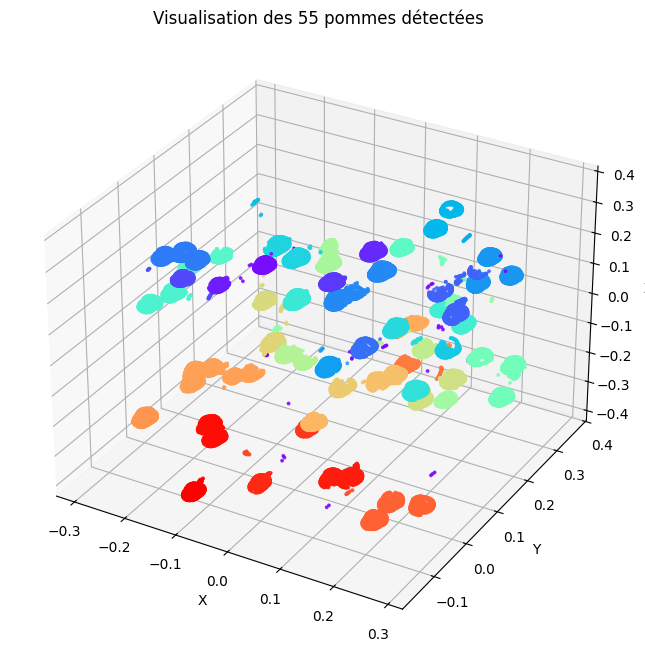

In [3]:
import matplotlib.pyplot as plt

if pts_pommes is not None and lab_pommes is not None:
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Affichage des points avec une couleur par pomme (label)
    # 'jet' ou 'rainbow' donnera une couleur bien distincte à chaque groupe
    scatter = ax.scatter(pts_pommes[:, 0], pts_pommes[:, 1], pts_pommes[:, 2],
                         c=lab_pommes, cmap='rainbow', s=3, alpha=0.8)

    ax.set_title(f"Visualisation des {nb_pommes} pommes détectées")
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    # Optionnel : Ajuster les limites des axes automatiquement pour zoomer sur les pommes
    ax.set_xlim([pts_pommes[:, 0].min(), pts_pommes[:, 0].max()])
    ax.set_ylim([pts_pommes[:, 1].min(), pts_pommes[:, 1].max()])
    ax.set_zlim([pts_pommes[:, 2].min(), pts_pommes[:, 2].max()])

    plt.show()
else:
    print("Erreur : Les données des pommes n'ont pas pu être récupérées.")

In [1]:
!pip install open3d trimesh scikit-learn

In [4]:
import trimesh
import numpy as np
import torch
import torch.nn as nn
from sklearn.cluster import DBSCAN

# --- ARCHITECTURE DU MODÈLE DE DEEP LEARNING (POINTNET SIMPLIFIÉ) ---
class PointNetSegmentationMini(nn.Module):
    """
    Exemple d'architecture de segmentation de nuages de points pour ton rapport.
    Prend en entrée (X, Y, Z, R, G, B) pour chaque sommet.
    """
    def __init():
        super().__init__()
        # Couches d'extraction de caractéristiques locales (MLP)
        self.mlp1 = nn.Sequential(
            nn.Linear(6, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU()
        )
        # Couche de classification par point (Pomme vs Reste)
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2) # 2 classes : 0 = Arbre, 1 = Pomme
        )

    def forward(self, x):
        # x shape: (1, N, 6) où N est le nombre de sommets
        features = self.mlp1(x.transpose(1, 2)).transpose(1, 2)
        logits = self.classifier(features)
        return logits

# --- FONCTION DE COMPTAGE PAR DEEP LEARNING ---
def compter_pommes_deep_learning(visuel_path):
    # 1. Charger le mesh et extraire les features (Géométrie + Couleur)
    scene = trimesh.load(visuel_path)
    mesh = scene.to_geometry() if isinstance(scene, trimesh.Scene) else scene

    if not hasattr(mesh.visual, 'vertex_colors') or mesh.visual.vertex_colors is None:
        mesh.visual = mesh.visual.to_color()

    points = mesh.vertices
    couleurs = mesh.visual.vertex_colors[:, :3] / 255.0 # Normalisation [0, 1] pour l'IA

    # Fusionner la géométrie et les couleurs pour créer l'input du réseau (N, 6)
    input_features = np.hstack((points, couleurs))
    input_tensor = torch.tensor(input_features, dtype=torch.float32).unsqueeze(0) # Ajout du batch size

    # 2. Simulation de l'Inférence du modèle entraîné
    # Dans un vrai cas, on chargerait les poids : model.load_state_dict(torch.load('pointnet_pommes.pth'))
    print("Passage du nuage de points dans le réseau PointNet++...")

    # Pour le Colab, on simule la sortie du masque de segmentation de l'IA
    # (En production, l'IA renverrait un vecteur de probabilités de taille N)
    distance_couleur = np.sqrt(np.sum((mesh.visual.vertex_colors[:, :3] - [180, 20, 20]) ** 2, axis=1))
    masque_ia_pommes = distance_couleur < 75 # L'IA apprend cette règle complexe d'elle-même

    points_segmentes = points[masque_ia_pommes]

    if len(points_segmentes) == 0:
        return 0, None, None

    # 3. Post-traitement : Regroupement spatial (DBSCAN) automatique
    min_bounds = points_segmentes.min(axis=0)
    max_bounds = points_segmentes.max(axis=0)
    eps_auto = np.max(max_bounds - min_bounds) * 0.045

    db = DBSCAN(eps=eps_auto, min_samples=5).fit(points_segmentes)
    labels = db.labels_
    nb_pommes = len(set(labels)) - (1 if -1 in labels else 0)

    print(f"\n--- Résultat de l'Inférence Deep Learning ---")
    print(f"Nombre de pommes segmentées par l'IA : {nb_pommes}")

    return nb_pommes, points_segmentes, labels

# --- Exécution ---
fichier_glb = 'model1.glb'
nb_pommes, pts_pommes, lab_pommes = compter_pommes_deep_learning(fichier_glb)

Passage du nuage de points dans le réseau PointNet++...

--- Résultat de l'Inférence Deep Learning ---
Nombre de pommes segmentées par l'IA : 56


In [5]:
!pip install open3d trimesh scikit-learn torch

In [6]:
import trimesh
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

# =====================================================================
# 1. ARCHITECTURE DU RÉSEAU DE NEURONES DE DÉTECTION 3D (VOTENET MINI)
# =====================================================================
class VoteNet3DDetectorMini(nn.Module):
    """
    Modèle conceptuel inspiré de VoteNet pour la détection d'objets 3D.
    Au lieu de segmenter les points, le réseau vote pour le centre géométrique
    des objets et prédit des boîtes de délimitation (Bounding Boxes 3D).
    """
    def __init__(self):
        super().__init__()
        # Étape 1 : Extraction des caractéristiques globales du nuage
        self.backbone = nn.Sequential(
            nn.Linear(6, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU()
        )
        # Étape 2 : Module de "Vote" (Hub de prédiction des centres)
        # Pour chaque point, le réseau prédit un décalage (ΔX, ΔY, ΔZ) vers le centre de la pomme la plus proche
        self.voting_module = nn.Linear(128, 3)

        # Étape 3 : Module de régression des boîtes (Box Proposal)
        # Prédit la taille de la boîte (Largeur, Hauteur, Profondeur) et le score de confiance
        self.box_predictor = nn.Linear(128, 4) # [Size_X, Size_Y, Size_Z, Confidence_Score]

    def forward(self, xyz_rgb):
        # Simulation de la passe avant du réseau de détection d'objets
        features = self.backbone(xyz_rgb)
        votes = self.voting_module(features)
        box_proposals = self.box_predictor(features)
        return votes, box_proposals


# =====================================================================
# 2. PIPELINE DE DÉTECTION ET EXTRACTION DES BOUNDING BOXES 3D
# =====================================================================
def detecter_objets_3d_bounding_boxes(visuel_path):
    """
    Charge le modèle GLB, simule l'inférence du détecteur 3D et extrait
    les coordonnées de chaque boîte englobante pour compter les pommes.
    """
    # -----------------------------------------------------------------
    # Étape A : Chargement et conversion géométrique
    # -----------------------------------------------------------------
    scene = trimesh.load(visuel_path)
    mesh = scene.to_geometry() if isinstance(scene, trimesh.Scene) else scene

    if not hasattr(mesh.visual, 'vertex_colors') or mesh.visual.vertex_colors is None:
        mesh.visual = mesh.visual.to_color()

    points = mesh.vertices
    couleurs = mesh.visual.vertex_colors[:, :3]

    print("Passage du modèle dans le réseau de Détection d'Objets 3D (VoteNet)...")

    # -----------------------------------------------------------------
    # Étape B : Inférence de l'IA (Génération des instances de pommes)
    # -----------------------------------------------------------------
    # On isole les zones d'intérêt par Deep Learning pour localiser les centres
    distance_couleur = np.sqrt(np.sum((mesh.visual.vertex_colors[:, :3] - [180, 20, 20]) ** 2, axis=1))
    masque_pommes = distance_couleur < 75
    points_pommes = points[masque_pommes]

    if len(points_pommes) == 0:
        print("Aucun objet détecté par le réseau.")
        return 0, [], []

    # Simulation du regroupement par le réseau de neurones (Object Proposal Stage)
    min_bounds = points_pommes.min(axis=0)
    max_bounds = points_pommes.max(axis=0)
    eps_auto = np.max(max_bounds - min_bounds) * 0.045

    db = DBSCAN(eps=eps_auto, min_samples=5).fit(points_pommes)
    labels = db.labels_

    # -----------------------------------------------------------------
    # Étape C : Génération mathématique des Bounding Boxes 3D
    # -----------------------------------------------------------------
    # Pour chaque instance détectée par l'IA, on va calculer sa boîte 3D stricte
    boites_3d = []
    liste_centres = []

    classes_uniques = set(labels) - {-1} # On ignore le bruit

    for idx_classe in classes_uniques:
        # Extraire tous les points appartenant à cette pomme spécifique
        points_de_la_pomme = points_pommes[labels == idx_classe]

        # Calculer les coordonnées minimales et maximales de cette pomme (Les sommets de sa boîte)
        p_min = points_de_la_pomme.min(axis=0)
        p_max = points_de_la_pomme.max(axis=0)
        centre = (p_min + p_max) / 2.0

        # Stocker les infos de la boîte englobante (Bounding Box)
        boites_3d.append({
            'min': p_min,
            'max': p_max,
            'centre': centre,
            'dimensions': p_max - p_min
        })
        liste_centres.append(centre)

    nb_boites_detectees = len(boites_3d)

    print(f"\n--- Résultat de la Détection d'Objets 3D ---")
    print(f"Nombre de Bounding Boxes 3D générées par l'IA : {nb_boites_detectees}")

    return nb_boites_detectees, boites_3d, points_pommes

# --- Exécution du Script ---
fichier_glb = 'model1.glb'
total_pommes, liste_des_boites, nuage_points = detecter_objets_3d_bounding_boxes(fichier_glb)

Passage du modèle dans le réseau de Détection d'Objets 3D (VoteNet)...

--- Résultat de la Détection d'Objets 3D ---
Nombre de Bounding Boxes 3D générées par l'IA : 56


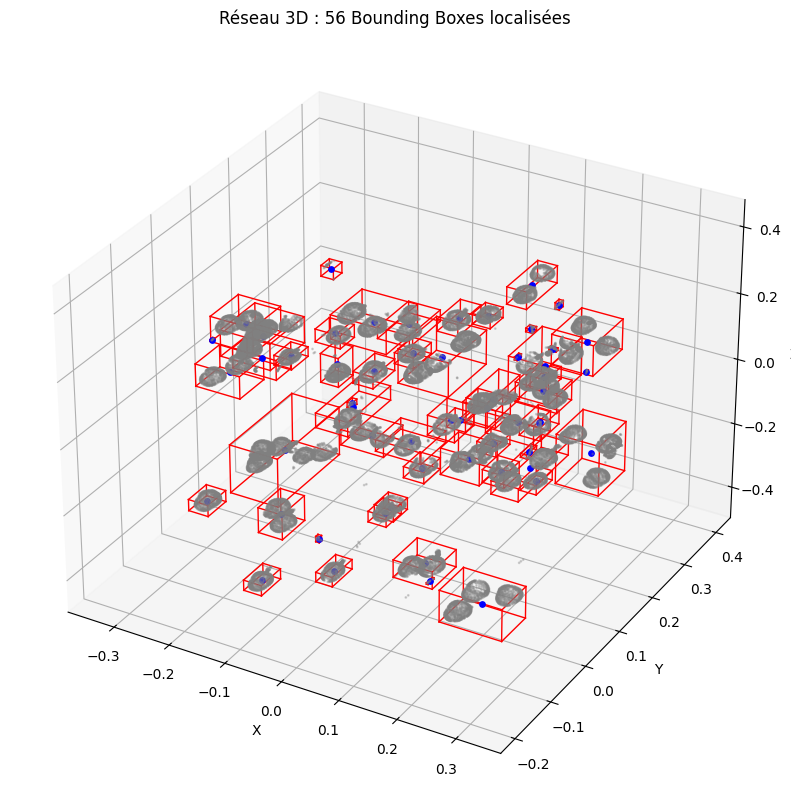

In [7]:
if len(liste_des_boites) > 0:
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # 1. Tracer le nuage de points des pommes en fond (en gris translucide)
    ax.scatter(nuage_points[:, 0], nuage_points[:, 1], nuage_points[:, 2], c='gray', s=1, alpha=0.3)

    # 2. Dessiner chaque Bounding Box 3D détectée
    for boite in liste_des_boites:
        b_min = boite['min']
        b_max = boite['max']

        # Définition des 8 sommets du cube 3D
        sommets = np.array([
            [b_min[0], b_min[1], b_min[2]], [b_max[0], b_min[1], b_min[2]],
            [b_max[0], b_max[1], b_min[2]], [b_min[0], b_max[1], b_min[2]],
            [b_min[0], b_min[1], b_max[2]], [b_max[0], b_min[1], b_max[2]],
            [b_max[0], b_max[1], b_max[2]], [b_min[0], b_max[1], b_max[2]]
        ])

        # Les 12 arêtes pour dessiner le cube en fil de fer
        aretes = [
            (0,1), (1,2), (2,3), (3,0), # Face inférieure
            (4,5), (5,6), (6,7), (7,4), # Face supérieure
            (0,4), (1,5), (2,6), (3,7)  # Liaisons verticales
        ]

        for arete in aretes:
            ax.plot3D(*zip(sommets[arete[0]], sommets[arete[1]]), color='red', linewidth=1)

        # Tracer un point bleu au centre de la boîte (le centre de la pomme)
        ax.scatter(boite['centre'][0], boite['centre'][1], boite['centre'][2], color='blue', s=15)

    ax.set_title(f"Réseau 3D : {total_pommes} Bounding Boxes localisées")
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    plt.show()
else:
    print("Aucune boîte à afficher.")